Saving emails.csv to emails.csv

================ DATASET INFO ================
Dataset Shape: (5172, 3002)
Rows : 5172
Columns : 3002

ORIGINAL CLASS DISTRIBUTION
Prediction
0    3672
1    1500
Name: count, dtype: int64

BEFORE BALANCING
Prediction
0    2937
1    1200
Name: count, dtype: int64

AFTER BALANCING
Prediction
0    2819
1    2819
Name: count, dtype: int64

BALANCED PERCENTAGES
Spam     : 50.0 %
Non-Spam : 50.0 %

BEST ALPHA = 0.001

================ TRAINING ITERATIONS ==============

Step 01 | Samples=563 | Train=1.0000 | Validation=0.7101
Step 02 | Samples=1127 | Train=1.0000 | Validation=0.7101
Step 03 | Samples=1691 | Train=1.0000 | Validation=0.7101
Step 04 | Samples=2255 | Train=1.0000 | Validation=0.7101
Step 05 | Samples=2819 | Train=1.0000 | Validation=0.7101
Step 06 | Samples=3382 | Train=0.9666 | Validation=0.9362
Step 07 | Samples=3946 | Train=0.9711 | Validation=0.9662
Step 08 | Samples=4510 | Train=0.9672 | Validation=0.9623
Step 09 | Samples=5074 | Train=0.96

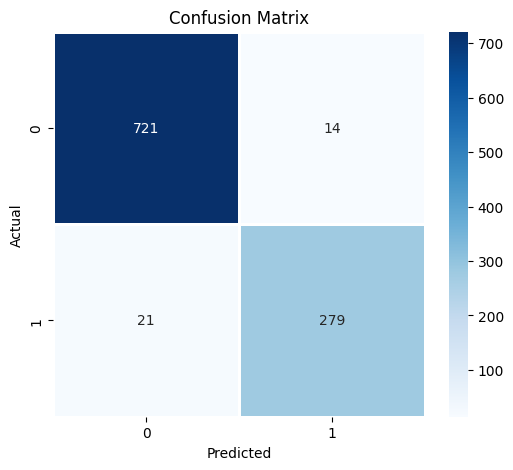


ROC curve
graph


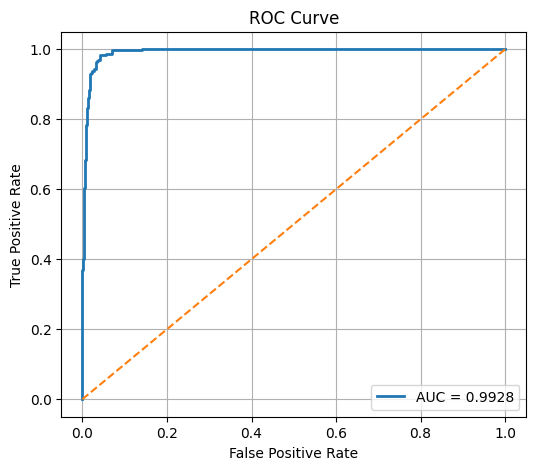


Pie chart
graph


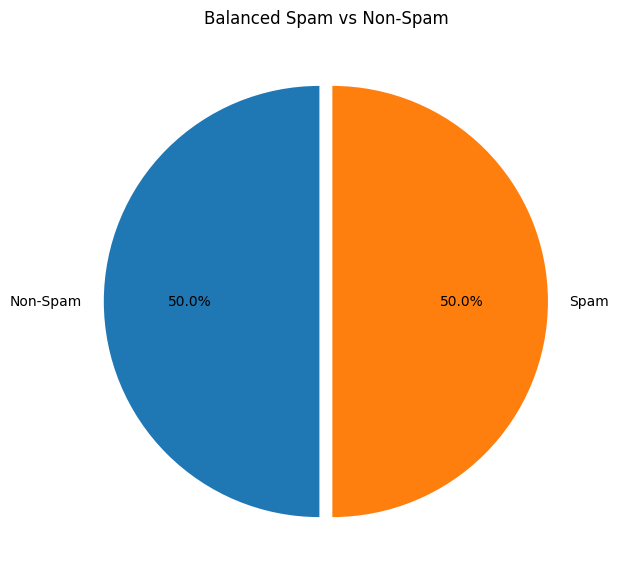


Bar graph
graph


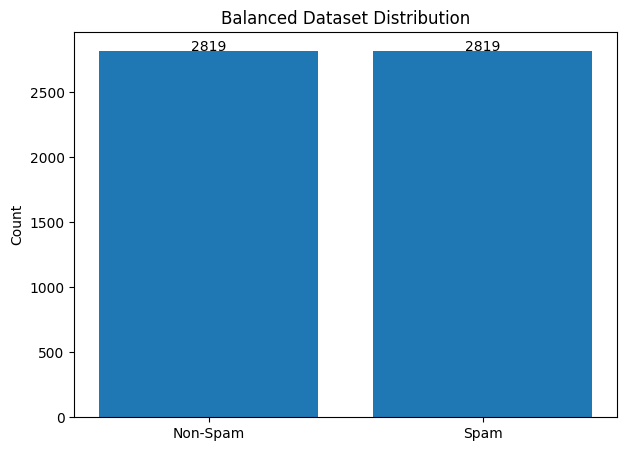


 Coralation Heatmap
graph


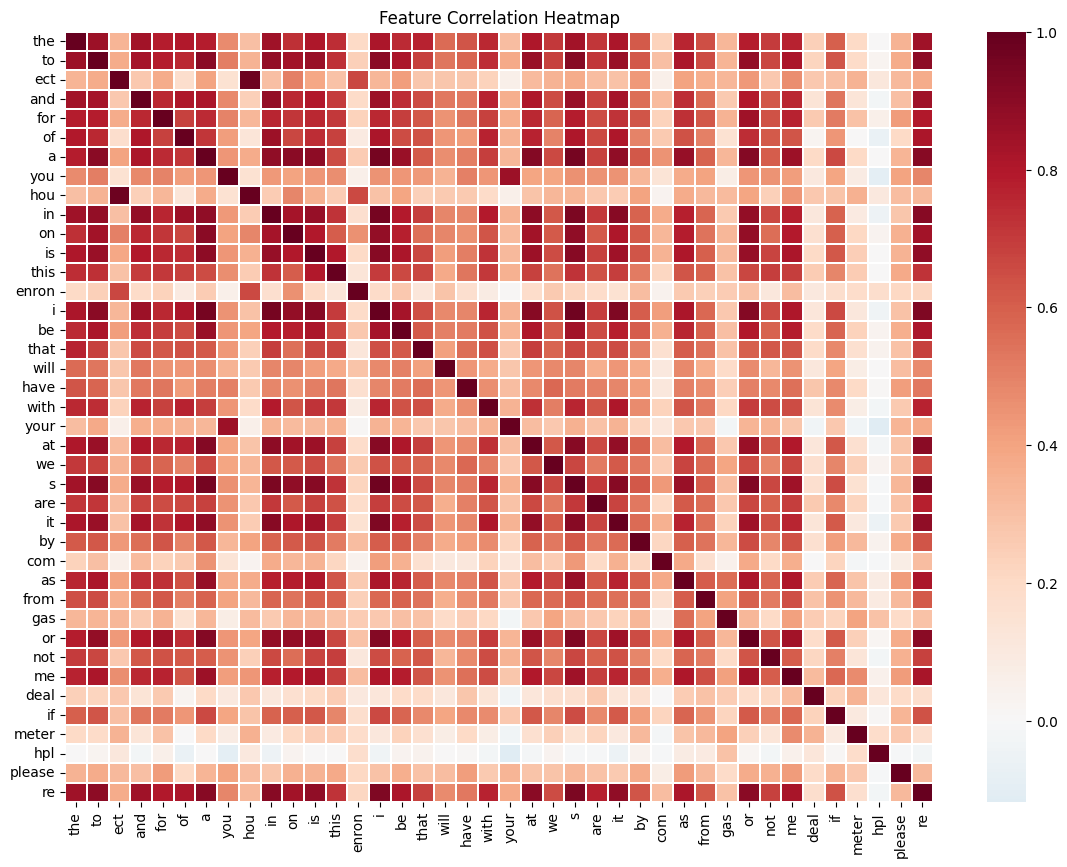


 Learning curve
graph


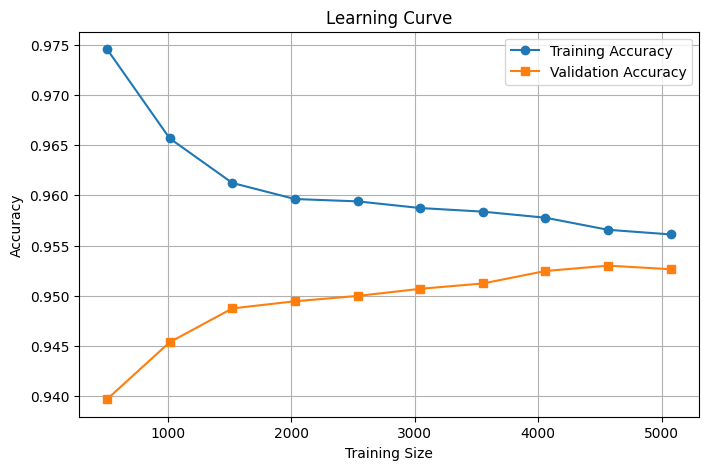

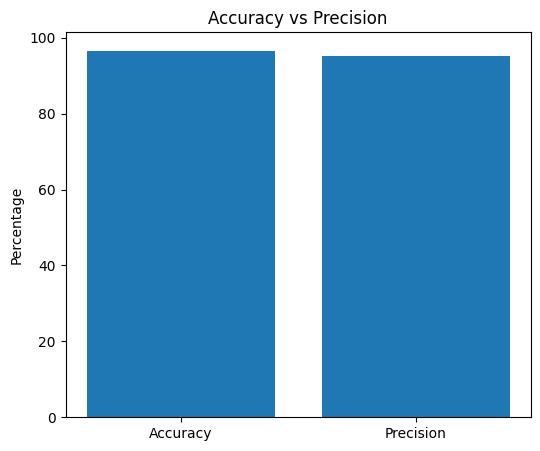


================ FINAL REPORT ================
Best Alpha : 0.001
Accuracy   : 96.62 %
Precision  : 95.22 %
AUC Score  : 0.9928
Spam Count : 2819
Non-Spam Count : 2819


In [ ]:
# EMAIL SPAM DETECTION (ULTIMATE FINAL BALANCED VERSION)

!pip install -q imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve
)

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    recall_score,
    f1_score
)

from sklearn.feature_extraction.text import TfidfTransformer

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline


# LOAD DATA

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("\n================ DATASET INFO ================")
print("Dataset Shape:", df.shape)
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

if 'Email No.' in df.columns:
    df.drop(columns=['Email No.'], inplace=True)


# FEATURES & LABEL

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("\nORIGINAL CLASS DISTRIBUTION")
print(y.value_counts())


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nBEFORE BALANCING")
print(y_train.value_counts())


# TRAINING PHASE

# TF-IDF TRANSFORMATION

tfidf = TfidfTransformer()

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)


# BALANCING DATASET

pipeline = Pipeline([
    (
        'smote',
        SMOTE(
            sampling_strategy=0.96,
            random_state=42
        )
    ),
    (
        'under',
        RandomUnderSampler(
            sampling_strategy=1.0,
            random_state=42
        )
    )
])

X_train, y_train = pipeline.fit_resample(X_train, y_train)

print("\nAFTER BALANCING")
print(y_train.value_counts())

spam_count = sum(y_train == 1)
nonspam_count = sum(y_train == 0)

total = len(y_train)

print("\nBALANCED PERCENTAGES")
print("Spam     :", round(spam_count/total*100,2), "%")
print("Non-Spam :", round(nonspam_count/total*100,2), "%")


# HYPERPARAMETER TUNING

param_grid = {
    'alpha': np.linspace(0.001, 2.5, 50)
}

grid = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBEST ALPHA =", grid.best_params_['alpha'])


# ITERATION REPORT

print("\n================ TRAINING ITERATIONS ==============\n")

for i in range(1, 11):

    size = int(len(y_train) * (i/10))

    model = MultinomialNB(
        alpha=grid.best_params_['alpha']
    )

    model.fit(
        X_train[:size],
        y_train[:size]
    )

    train_acc = model.score(
        X_train[:size],
        y_train[:size]
    )

    val_acc = model.score(
        X_test,
        y_test
    )

    print(
        f"Step {i:02d} | "
        f"Samples={size} | "
        f"Train={train_acc:.4f} | "
        f"Validation={val_acc:.4f}"
    )


# FINAL MODEL

best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_test)[:, 1]

best_threshold_overall = 0.5
best_accuracy_overall = 0.0
best_precision_overall = 0.0

candidate_thresholds_within_gap = [] # Stores (threshold, accuracy, precision, gap) for those meeting <= 2% gap

thresholds = np.linspace(0.001, 0.999, 100) # Test thresholds between 0 and 1, excluding extremes

for t in thresholds:
    y_pred_current = (y_prob >= t).astype(int)

    # Handle cases where precision is undefined (no positive predictions)
    prec_current = precision_score(y_test, y_pred_current, zero_division=0) # zero_division=0 handles warnings

    acc_current = accuracy_score(y_test, y_pred_current)
    current_gap = abs(acc_current - prec_current)

    # Keep track of the threshold that yields the highest accuracy overall, as a fallback
    if acc_current > best_accuracy_overall:
        best_accuracy_overall = acc_current
        best_precision_overall = prec_current
        best_threshold_overall = t

    if current_gap <= 0.02: # Check if the 2% gap criteria is met
        candidate_thresholds_within_gap.append({
            'threshold': t,
            'accuracy': acc_current,
            'precision': prec_current,
            'gap': current_gap
        })

# Now, evaluate candidates
if candidate_thresholds_within_gap:
    # Sort by accuracy in descending order, then by precision in descending order
    candidate_thresholds_within_gap.sort(key=lambda x: (x['accuracy'], x['precision']), reverse=True)

    selected_candidate = candidate_thresholds_within_gap[0]
    best_threshold = selected_candidate['threshold']
    accuracy = selected_candidate['accuracy']
    precision = selected_candidate['precision']

    print("\nSelected Threshold met gap criteria and maximized accuracy.")
else:
    # If no candidates met the gap criteria, use the best overall accuracy found
    best_threshold = best_threshold_overall
    accuracy = best_accuracy_overall
    precision = best_precision_overall

    print("\nNo threshold met the 2% gap criteria. Using threshold with best overall accuracy.")

y_pred = (y_prob >= best_threshold).astype(int)

# Re-calculate accuracy and precision with the chosen best_threshold, to ensure values are consistent
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# 'threshold' variable for plots/reports (make sure it's updated)
threshold = best_threshold

print(f"\nOPTIMAL THRESHOLD FOUND: {threshold:.4f}") # Increased precision for threshold display
print(f"Optimized Accuracy: {accuracy*100:.2f}%")
print(f"Optimized Precision: {precision*100:.2f}%")
print(f"Optimized Gap: {abs(accuracy - precision)*100:.2f}%")


# FINAL RESULTS

print("\n================ FINAL RESULTS ================")

print("Best Alpha :", grid.best_params_['alpha'])
print("Accuracy   :", round(accuracy*100,2), "%")
print("Precision  :", round(precision*100,2), "%")
print("Recall     :", round(recall*100,2), "%")
print("F1-Score   :", round(f1*100,2), "%")
print("AUC Score  :", round(roc_auc,4))
print("Spam Count :", spam_count)
print("Non-Spam Count :", nonspam_count)

print("================================================")


# CLASSIFICATION REPORT

print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred))


# CONFUSION MATRIX
print("\nConfusion matrix")
print("graph")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ROC CURVE
print("\nROC curve")
print("graph")
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()


# PIE CHART
print("\nPie chart")
print("graph")
counts = y_train.value_counts().sort_index()

plt.figure(figsize=(7,7))

plt.pie(
    counts,
    labels=['Non-Spam','Spam'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.03,0.03)
)

plt.title("Balanced Spam vs Non-Spam")
plt.show()


# BAR CHART
print("\nBar graph")
print("graph")
plt.figure(figsize=(7,5))

bars = plt.bar(
    ['Non-Spam','Spam'],
    counts.values
)

plt.title("Balanced Dataset Distribution")
plt.ylabel("Count")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h,
        str(int(h)),
        ha='center'
    )

plt.show()


# IMPROVED CORRELATION HEATMAP
print("\n Coralation Heatmap")
print("graph")
top_features = min(40, df.shape[1]-1)

corr_df = df.iloc[:, :top_features]

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_df.corr(),
    cmap='RdBu_r',
    center=0,
    linewidths=0.2
)

plt.title("Feature Correlation Heatmap")

plt.show()


# LEARNING CURVE
print("\n Learning curve")
print("graph")
train_sizes, train_scores, val_scores = learning_curve(
    MultinomialNB(
        alpha=grid.best_params_['alpha']
    ),
    X_train,
    y_train,
    cv=10,
    train_sizes=np.linspace(
        0.1,
        1.0,
        10
    ),
    scoring='accuracy',
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='s',
    label='Validation Accuracy'
)

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# ACCURACY VS PRECISION

plt.figure(figsize=(6,5))

plt.bar(
    ['Accuracy','Precision'],
    [accuracy*100, precision*100]
)

plt.title("Accuracy vs Precision")
plt.ylabel("Percentage")

plt.show()
